<a href="https://colab.research.google.com/github/hedonistmahin/Data/blob/main/Thesis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ============================================================
# THESIS: An Explainable Machine Learning Based Clinical
#         Decision Support System for Medical Test Report Analysis
# Author : Md. Modabbir Hossain Mahin (UG02-61-22-036)
#          Tarannum Tasnim Samara     (UG02-61-22-032)
## ==========================================================


# CELL 1 ─ Install Dependencies


In [7]:
!pip install shap lime xgboost scikit-learn matplotlib seaborn pandas numpy -q

# CELL 2 ─ Imports


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing   import LabelEncoder, StandardScaler
from sklearn.linear_model    import LogisticRegression
from sklearn.tree            import DecisionTreeClassifier
from sklearn.ensemble        import RandomForestClassifier
from sklearn.metrics         import (accuracy_score, precision_score, recall_score,
                                     f1_score, roc_auc_score, confusion_matrix,
                                     classification_report, roc_curve, auc)
# XGBoost
from xgboost import XGBClassifier

# XAI
import shap
import lime
import lime.lime_tabular

# Display
from IPython.display import display

# Reproducibility
SEED = 42
np.random.seed(SEED)

print("✅ All libraries loaded successfully.")

✅ All libraries loaded successfully.


# CELL 3 ─ Load Dataset

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
df = pd.read_csv('/content/drive/MyDrive/Dataset/CDSS_full_dataset_50k_clean.csv')

print(f"Dataset shape : {df.shape}")
print(f"Columns       : {list(df.columns)}")
df.head()

Dataset shape : (50000, 38)
Columns       : ['seqn', 'age', 'gender', 'race_ethnicity', 'smoking_status', 'bmi', 'waist_cm', 'sbp', 'dbp', 'chol_total', 'chol_hdl', 'chol_ldl', 'triglycerides', 'glucose', 'hba1c', 'hscrp', 'creatinine', 'bun', 'albumin', 'alt', 'ast', 'alp', 'total_bilirubin', 'total_protein', 'hemoglobin', 'hematocrit', 'rbc', 'wbc', 'platelets', 'ferritin', 'serum_iron', 'diabetes_self_reported', 'cvd_self_reported', 'ckd_self_reported', 'antihypertensive_rx', 'statin_rx', 'diabetes_rx', 'risk_label']


,seqn,age,gender,race_ethnicity,smoking_status,bmi,waist_cm,sbp,dbp,chol_total,...,platelets,ferritin,serum_iron,diabetes_self_reported,cvd_self_reported,ckd_self_reported,antihypertensive_rx,statin_rx,diabetes_rx,risk_label
0,100000,66.2,Male,Asian,Former,23.9,55.0,136,70,161.0,...,287.0,270.2,99.5,0,0,1,1,0,0,Low
1,100001,7.0,Female,Other,Former,26.8,55.0,114,50,207.9,...,259.0,67.3,103.0,0,0,0,0,1,0,Low
2,100002,61.0,Female,Non-Hispanic White,Never,26.5,55.0,111,80,156.1,...,189.0,89.3,85.3,0,0,0,0,0,0,Low
3,100003,62.6,Male,Hispanic,Never,29.6,64.4,133,74,222.9,...,257.0,123.2,129.5,0,1,0,1,0,0,Low
4,100004,10.8,Male,Hispanic,Never,29.4,61.7,112,58,175.1,...,305.0,111.1,91.7,0,0,0,0,0,0,Low


# CELL 4 ─ Exploratory Data Analysis

In [11]:
print("=" * 50)
print("BASIC INFO")
print("=" * 50)
print(df.info())

print("\n" + "=" * 50)
print("MISSING VALUES")
print("=" * 50)
missing = df.isnull().sum()
missing = missing[missing > 0]
print(missing if len(missing) > 0 else "No missing values found ✅")

print("\n" + "=" * 50)
print("CLASS DISTRIBUTION (risk_label)")
print("=" * 50)
print(df['risk_label'].value_counts())

BASIC INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 38 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   seqn                    50000 non-null  int64  
 1   age                     50000 non-null  float64
 2   gender                  50000 non-null  object 
 3   race_ethnicity          50000 non-null  object 
 4   smoking_status          50000 non-null  object 
 5   bmi                     50000 non-null  float64
 6   waist_cm                50000 non-null  float64
 7   sbp                     50000 non-null  int64  
 8   dbp                     50000 non-null  int64  
 9   chol_total              50000 non-null  float64
 10  chol_hdl                50000 non-null  float64
 11  chol_ldl                50000 non-null  float64
 12  triglycerides           50000 non-null  float64
 13  glucose                 50000 non-null  float64
 14  hba1c                   500

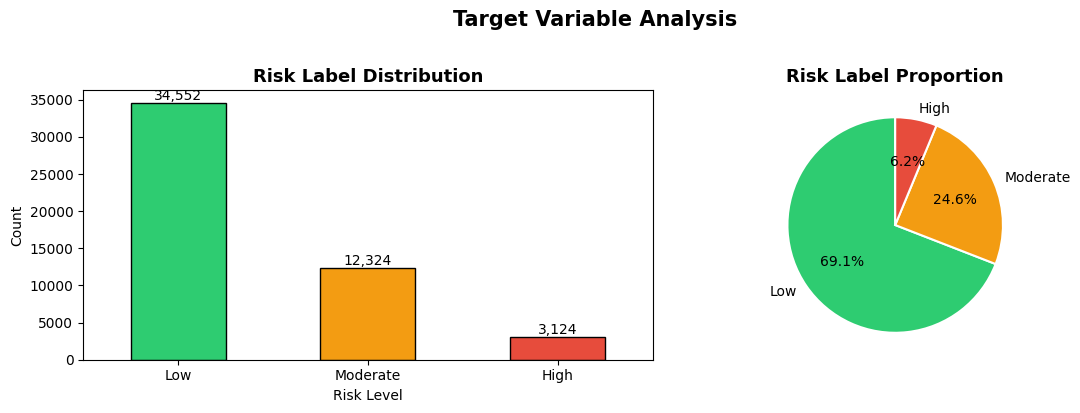

In [12]:
# ── Plot 1: Risk Label Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#2ecc71', '#f39c12', '#e74c3c']

df['risk_label'].value_counts().plot(
    kind='bar', ax=axes[0], color=colors, edgecolor='black', width=0.5
)
axes[0].set_title('Risk Label Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Risk Level')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=10)

df['risk_label'].value_counts().plot(
    kind='pie', ax=axes[1], colors=colors, autopct='%1.1f%%',
    startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[1].set_title('Risk Label Proportion', fontsize=13, fontweight='bold')
axes[1].set_ylabel('')

plt.suptitle('Target Variable Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

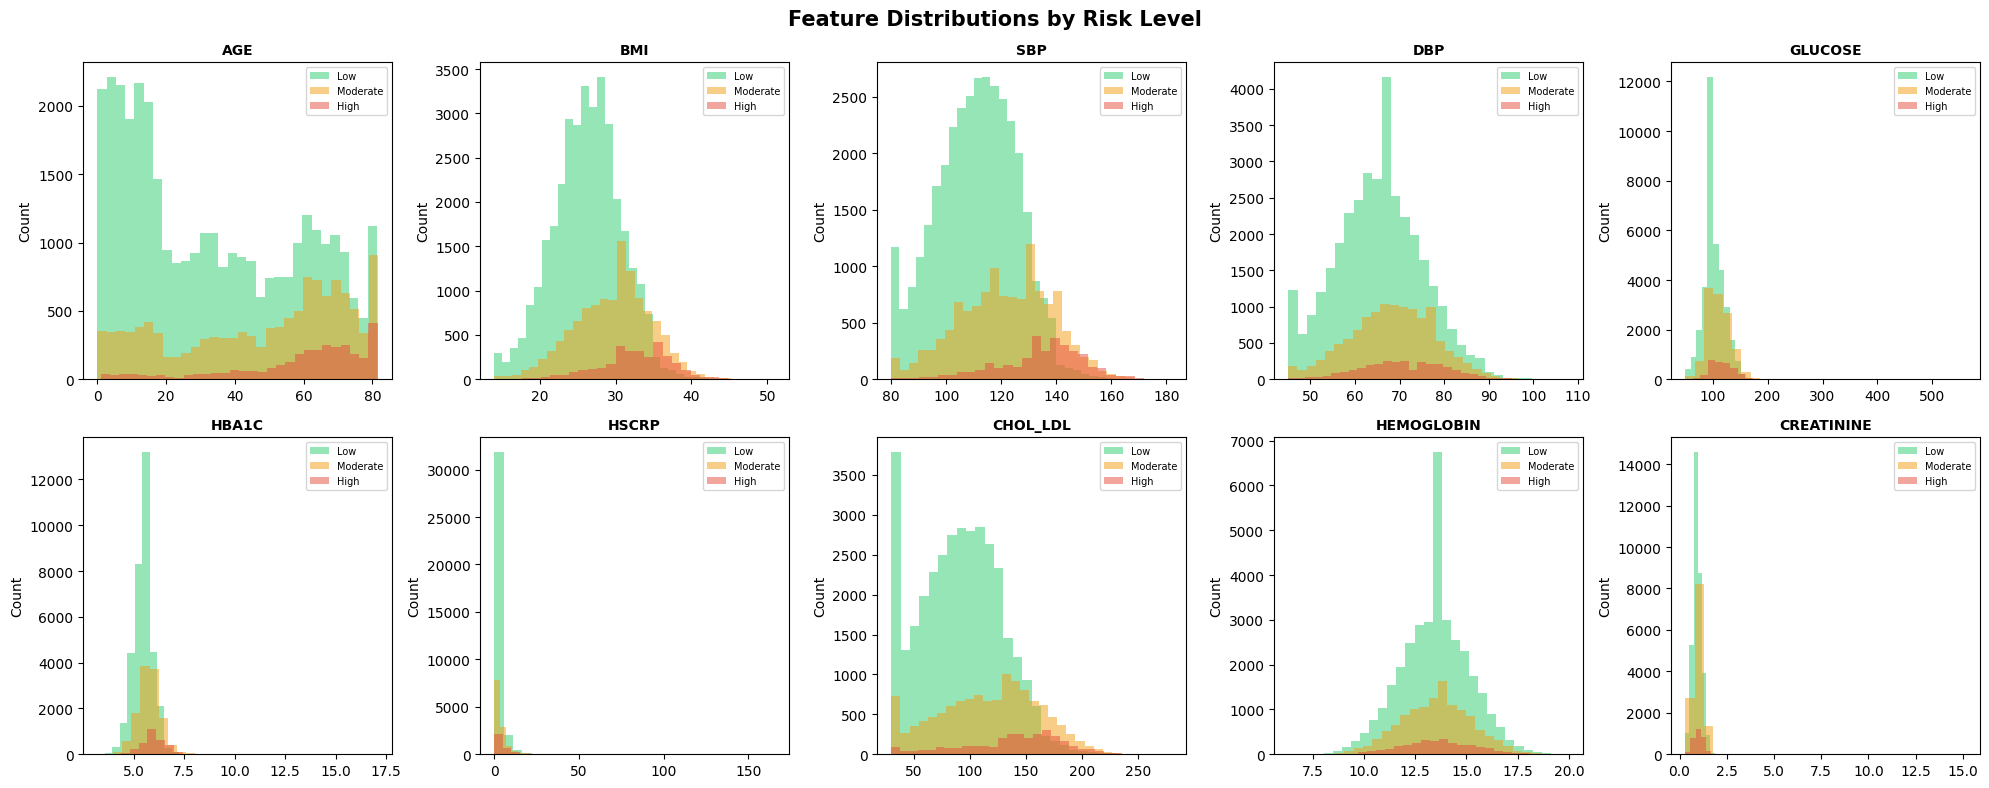

In [13]:
# ── Plot 2: Distribution of key numerical features
numeric_features = ['age', 'bmi', 'sbp', 'dbp', 'glucose', 'hba1c',
                    'hscrp', 'chol_ldl', 'hemoglobin', 'creatinine']

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
palette = {'Low': '#2ecc71', 'Moderate': '#f39c12', 'High': '#e74c3c'}

for i, feat in enumerate(numeric_features):
    for label, color in palette.items():
        subset = df[df['risk_label'] == label][feat].dropna()
        axes[i].hist(subset, bins=30, alpha=0.5, color=color, label=label, edgecolor='none')
    axes[i].set_title(feat.upper(), fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=7)

plt.suptitle('Feature Distributions by Risk Level', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_02_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

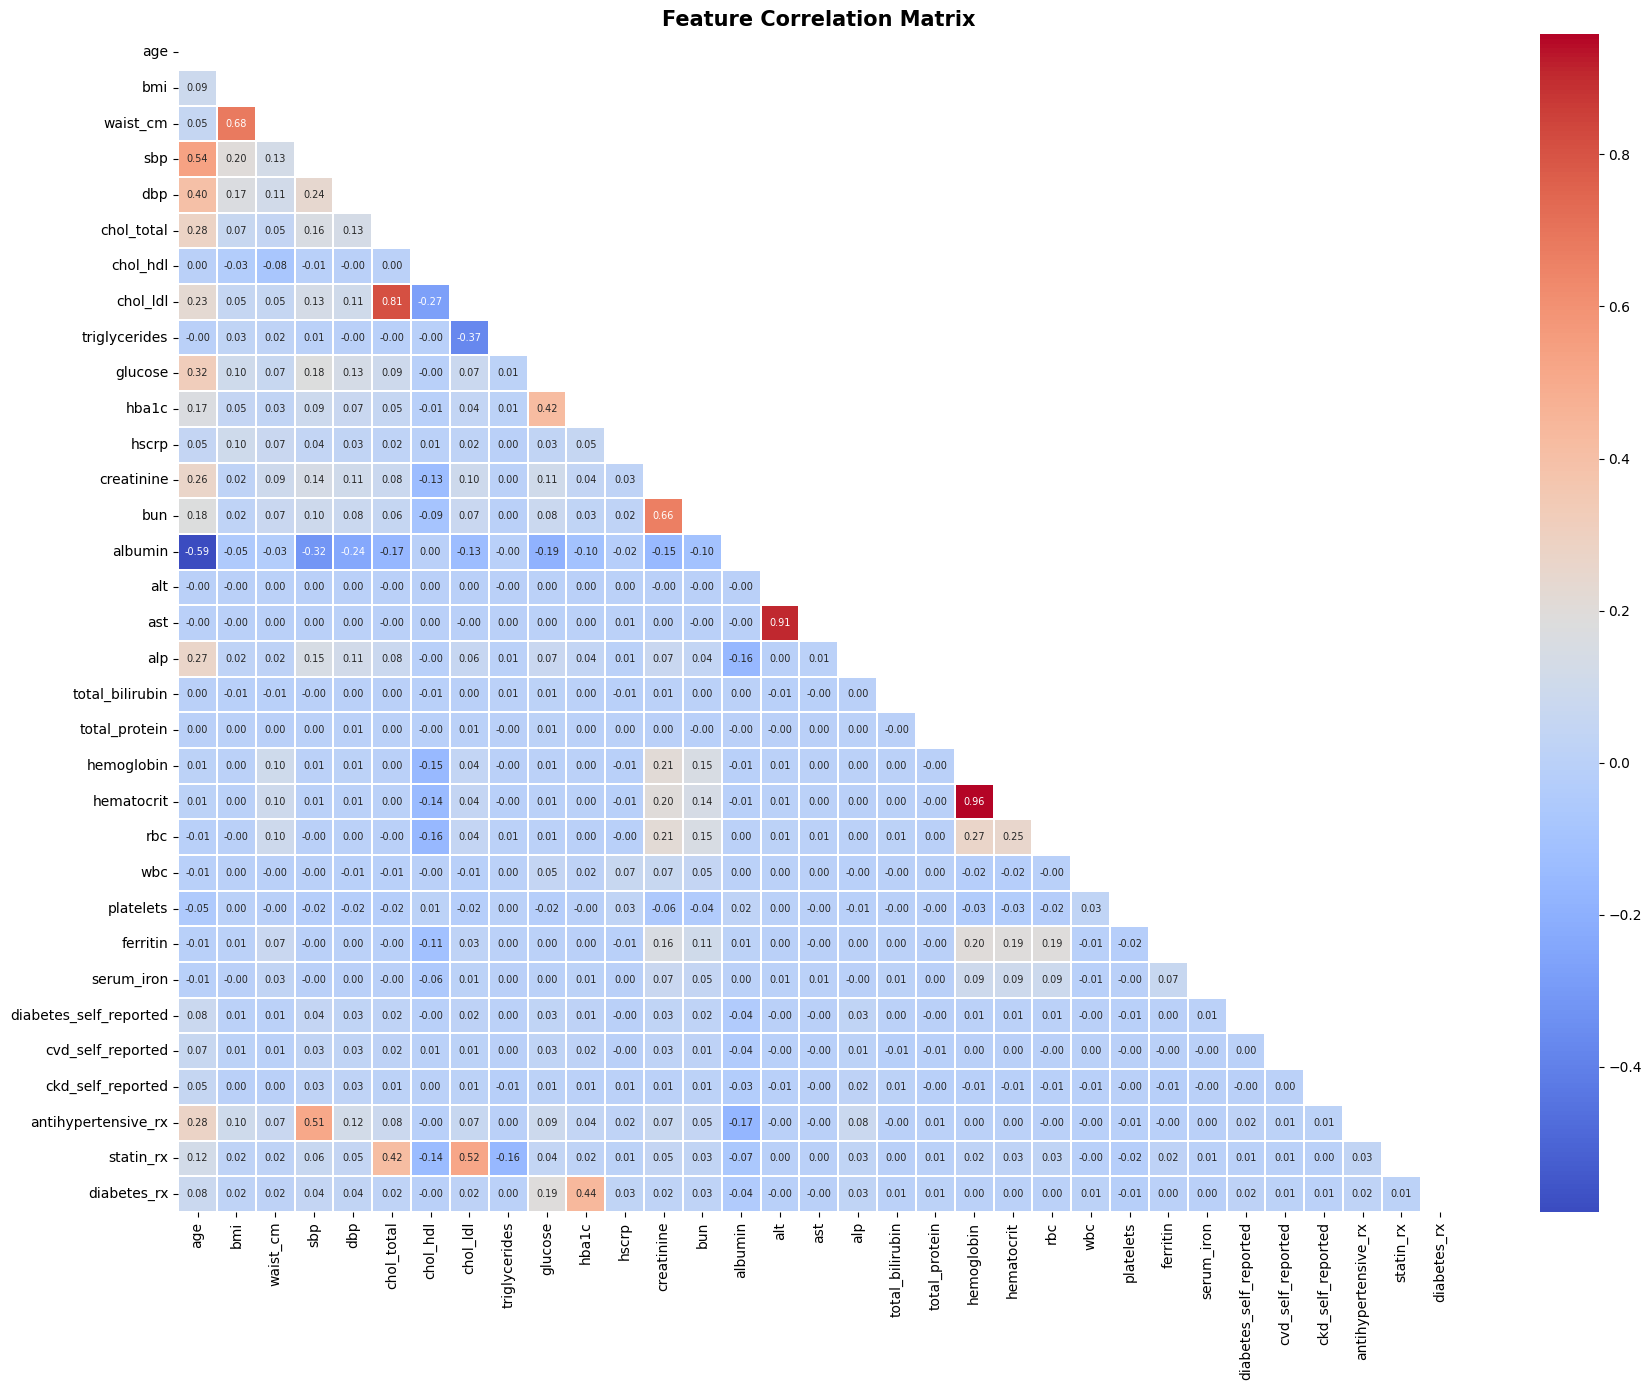

In [14]:
# ── Plot 3: Correlation Heatmap
num_cols = df.select_dtypes(include='number').columns.tolist()
num_cols = [c for c in num_cols if c != 'seqn']

fig, ax = plt.subplots(figsize=(18, 14))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.3, annot_kws={'size': 7}, ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_03_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# CELL 5 ─ Preprocessing

In [15]:
df_model = df.copy()

In [16]:
# Drop identifier
df_model.drop(columns=['seqn'], inplace=True, errors='ignore')

In [17]:
# ── Encode categorical features
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c != 'risk_label']
print(f"Categorical columns to encode: {cat_cols}")

le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    le_dict[col] = le

Categorical columns to encode: ['gender', 'race_ethnicity', 'smoking_status']


In [18]:
# ── Encode target
le_target = LabelEncoder()
df_model['risk_label'] = le_target.fit_transform(df_model['risk_label'])
label_names = list(le_target.classes_)
print(f"\nLabel encoding → {dict(zip(range(len(label_names)), label_names))}")


Label encoding → {0: 'High', 1: 'Low', 2: 'Moderate'}


In [19]:
# ── Handle missing values (median imputation)
df_model.fillna(df_model.median(numeric_only=True), inplace=True)

In [20]:
# ── Features / Target split
X = df_model.drop(columns=['risk_label'])
y = df_model['risk_label']
feature_names = X.columns.tolist()

print(f"\nFeature matrix shape : {X.shape}")
print(f"Target shape         : {y.shape}")
print(f"Classes              : {label_names}")


Feature matrix shape : (50000, 36)
Target shape         : (50000,)
Classes              : ['High', 'Low', 'Moderate']


In [21]:
# ── Train / Validation / Test split  (70 / 15 / 15)
X_temp, X_test,  y_temp, y_test  = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y)
X_train, X_val, y_train, y_val   = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=SEED, stratify=y_temp)

In [22]:
print(f"\nTrain : {X_train.shape[0]:,} ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Val   : {X_val.shape[0]:,}   ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test  : {X_test.shape[0]:,}  ({X_test.shape[0]/len(X)*100:.1f}%)")


Train : 34,998 (70.0%)
Val   : 7,502   (15.0%)
Test  : 7,500  (15.0%)


In [23]:
# ── Scale features (for Logistic Regression)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print("\n✅ Preprocessing complete.")


✅ Preprocessing complete.


# CELL 6 ─ Model Training

In [24]:
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=SEED, class_weight='balanced'),

    'Decision Tree': DecisionTreeClassifier(
        max_depth=10, min_samples_split=20, random_state=SEED,
        class_weight='balanced'),

    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=15, min_samples_split=10,
        random_state=SEED, class_weight='balanced', n_jobs=-1),

    'XGBoost': XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        use_label_encoder=False, eval_metric='mlogloss',
        random_state=SEED, n_jobs=-1),
}

In [25]:
# Train each model
trained_models = {}
for name, model in models.items():
    print(f"Training {name}...", end=' ')
    if name == 'Logistic Regression':
        model.fit(X_train_sc, y_train)
    else:
        model.fit(X_train, y_train)
    trained_models[name] = model
    print("Done ✅")

Training Logistic Regression... Done ✅
Training Decision Tree... Done ✅
Training Random Forest... Done ✅
Training XGBoost... Done ✅


# CELL 7 ─ Evaluation on Test Set

In [28]:
def evaluate_model(name, model, X_t, y_t, label_names):
    """Return a dict of all evaluation metrics."""
    y_pred = model.predict(X_t)

    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_t)
        roc_auc = roc_auc_score(y_t, y_prob, multi_class='ovr', average='weighted')
    else:
        roc_auc = np.nan

    return {
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_t, y_pred), 4),
        'Precision': round(precision_score(y_t, y_pred, average='weighted', zero_division=0), 4),
        'Recall'   : round(recall_score(y_t, y_pred, average='weighted', zero_division=0), 4),
        'F1-Score' : round(f1_score(y_t, y_pred, average='weighted', zero_division=0), 4),
        'ROC-AUC'  : round(roc_auc, 4),
        'y_pred'   : y_pred,
        'y_prob'   : y_prob if hasattr(model, 'predict_proba') else None,
    }

results = []
for name, model in trained_models.items():
    X_t = X_test_sc if name == 'Logistic Regression' else X_test
    res = evaluate_model(name, model, X_t, y_test, label_names)
    results.append(res)

In [29]:
# Build summary table
metrics_df = pd.DataFrame([{
    k: v for k, v in r.items() if k not in ('y_pred', 'y_prob')
} for r in results])

metrics_df = metrics_df.sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
print("\n" + "=" * 70)
print("MODEL PERFORMANCE COMPARISON (Test Set)")
print("=" * 70)
display(metrics_df)


MODEL PERFORMANCE COMPARISON (Test Set)


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,XGBoost,0.9919,0.9920,0.9919,0.9918,0.9997
1,Random Forest,0.9515,0.9518,0.9515,0.9503,0.9955
2,Decision Tree,0.9740,0.9749,0.9740,0.9743,0.9921
3,Logistic Regression,0.7980,0.8282,0.7980,0.8080,0.9228


In [30]:
# Save results
metrics_df.to_csv('model_performance.csv', index=False)

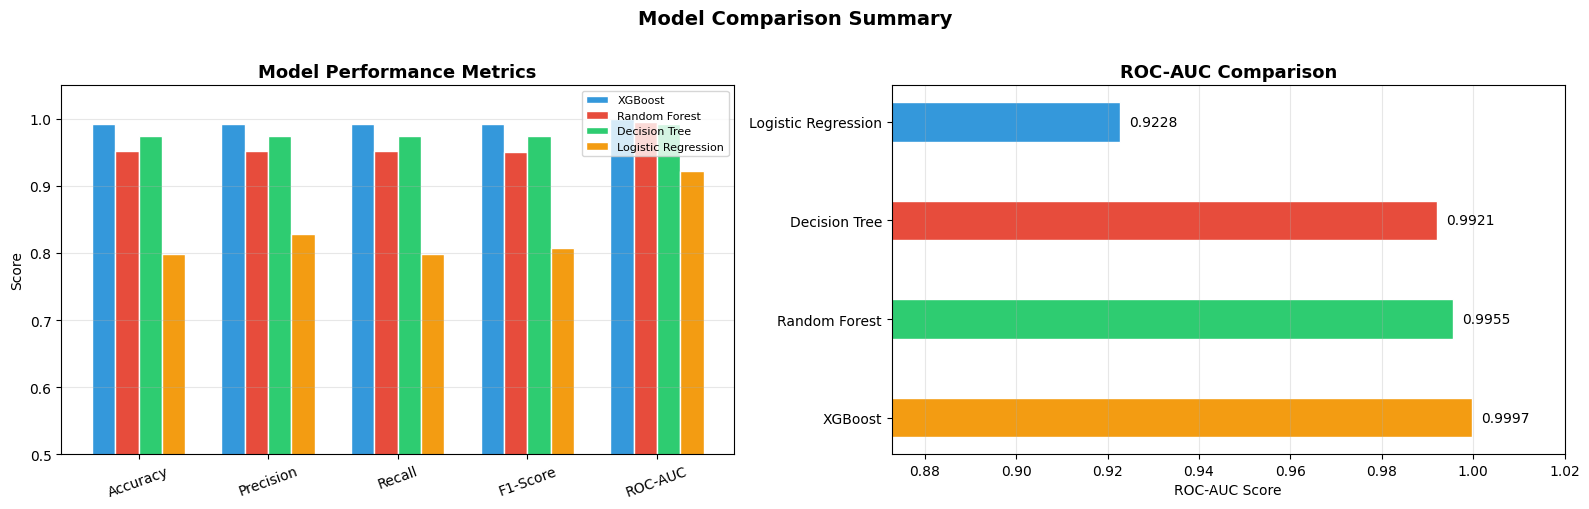

In [39]:
# ── Plot 4: Metrics Comparison Bar Chart
plt.close('all')  # ✅ kill any ghost figures from previous cells

metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
bar_colors  = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

# ✅ Fill NaN ROC-AUC with 0 so barh never renders empty
metrics_df['ROC-AUC'] = pd.to_numeric(metrics_df['ROC-AUC'], errors='coerce').fillna(0)

model_names = metrics_df['Model'].tolist()
roc_vals    = metrics_df['ROC-AUC'].values

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Left: grouped bar chart
x = np.arange(len(metric_cols))
w = 0.18

for i, (_, row) in enumerate(metrics_df.iterrows()):
    vals = [row[m] for m in metric_cols]
    axes[0].bar(x + i * w, vals, w,
                label=row['Model'], color=bar_colors[i], edgecolor='white')

axes[0].set_title('Model Performance Metrics', fontsize=13, fontweight='bold')
axes[0].set_xticks(x + w * 1.5)
axes[0].set_xticklabels(metric_cols, rotation=20)
axes[0].set_ylim(0.5, 1.05)
axes[0].set_ylabel('Score')
axes[0].legend(fontsize=8)
axes[0].grid(axis='y', alpha=0.3)

# ── Right: horizontal ROC-AUC bar chart
# ✅ Clamp xlim lower bound to just below min value so bars always appear
roc_min = max(0.5, roc_vals.min() - 0.05)
bars = axes[1].barh(model_names, roc_vals,
                    color=bar_colors[::-1], edgecolor='white', height=0.4)
axes[1].set_xlim(roc_min, 1.02)
axes[1].set_title('ROC-AUC Comparison', fontsize=13, fontweight='bold')
axes[1].set_xlabel('ROC-AUC Score')
axes[1].grid(axis='x', alpha=0.3)

for bar, val in zip(bars, roc_vals):
    axes[1].text(
        val + 0.002,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.4f}' if val > 0 else 'N/A',   # ✅ label NaN-replaced zeros clearly
        va='center', fontsize=10
    )

plt.suptitle('Model Comparison Summary', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_04_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)  # ✅ explicitly close this figure after showing

<Figure size 640x480 with 0 Axes>

# CELL 8 ─ Confusion Matrices

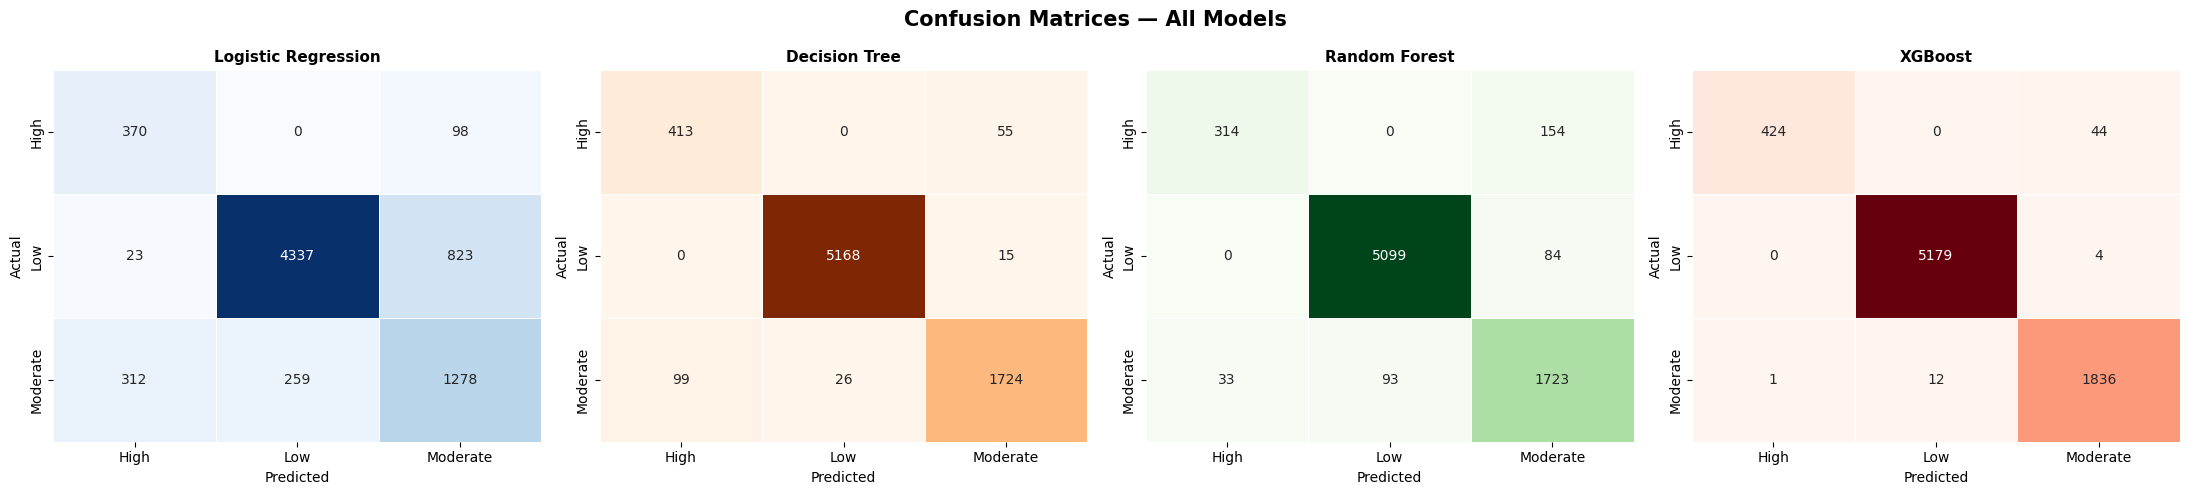

In [40]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
cmaps = ['Blues', 'Oranges', 'Greens', 'Reds']

for ax, res, cmap in zip(axes, results, cmaps):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=label_names, yticklabels=label_names,
                linewidths=0.5, ax=ax, cbar=False)
    ax.set_title(res['Model'], fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — All Models', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_05_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# CELL 9 ─ ROC Curves (One-vs-Rest per class)

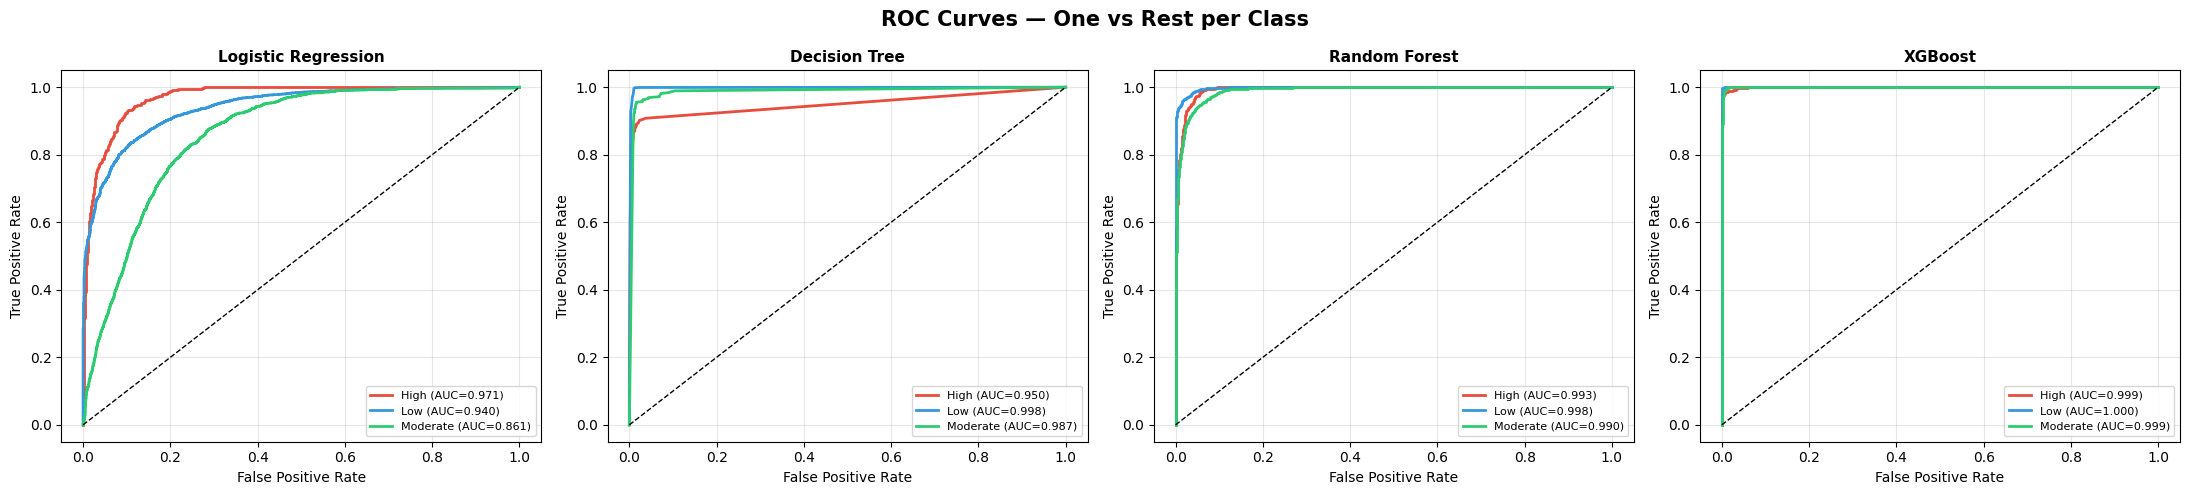

In [41]:
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes  = y_test_bin.shape[1]
line_styles = ['-', '--', ':']

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
colors_roc = ['#e74c3c', '#3498db', '#2ecc71']

for ax, res in zip(axes, results):
    if res['y_prob'] is None:
        continue
    for i, (cls, color) in enumerate(zip(label_names, colors_roc)):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], res['y_prob'][:, i])
        roc_auc_i   = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=color, lw=2,
                label=f'{cls} (AUC={roc_auc_i:.3f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_title(res['Model'], fontsize=11, fontweight='bold')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('ROC Curves — One vs Rest per Class', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_06_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# CELL 10 ─ Cross-Validation (5-Fold Stratified)

5-FOLD STRATIFIED CROSS-VALIDATION (F1-weighted)
  Logistic Regression   : Mean=0.8057  Std=0.0033  Scores=[0.8091 0.8    0.8056 0.8089 0.8049]
  Decision Tree         : Mean=0.9721  Std=0.0018  Scores=[0.9732 0.9711 0.974  0.9692 0.9729]
  Random Forest         : Mean=0.9502  Std=0.0018  Scores=[0.9505 0.9482 0.9518 0.9481 0.9526]
  XGBoost               : Mean=0.9888  Std=0.0010  Scores=[0.9898 0.9887 0.989  0.9895 0.9871]


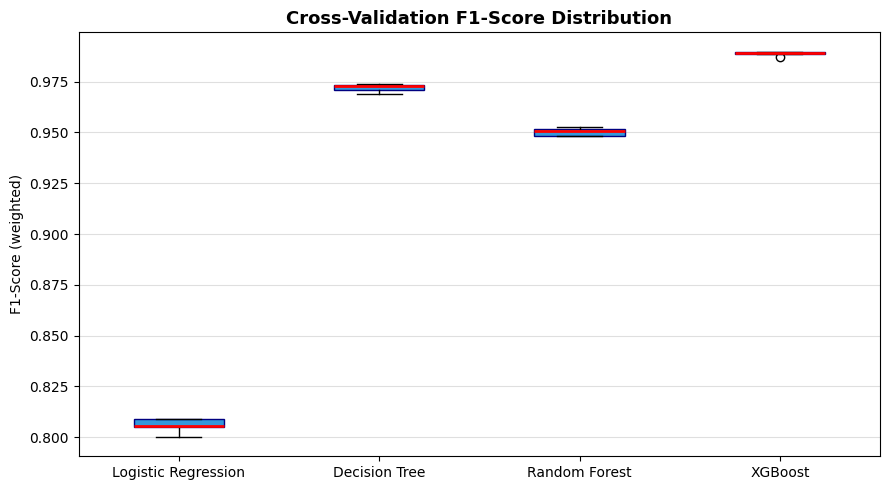

In [42]:
print("=" * 60)
print("5-FOLD STRATIFIED CROSS-VALIDATION (F1-weighted)")
print("=" * 60)

cv_results = {}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

for name, model in trained_models.items():
    X_cv = X_train_sc if name == 'Logistic Regression' else X_train
    scores = cross_val_score(model, X_cv, y_train,
                             cv=skf, scoring='f1_weighted', n_jobs=-1)
    cv_results[name] = scores
    print(f"  {name:<22}: Mean={scores.mean():.4f}  Std={scores.std():.4f}  "
          f"Scores={np.round(scores, 4)}")

# CV Box plot
fig, ax = plt.subplots(figsize=(9, 5))
ax.boxplot(cv_results.values(), labels=cv_results.keys(),
           patch_artist=True,
           boxprops=dict(facecolor='#3498db', color='navy'),
           medianprops=dict(color='red', linewidth=2))
ax.set_title('Cross-Validation F1-Score Distribution', fontsize=13, fontweight='bold')
ax.set_ylabel('F1-Score (weighted)')
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('plot_07_cross_validation.png', dpi=150, bbox_inches='tight')
plt.show()

# CELL 11 ─ Best Model Selection

🏆 BEST MODEL : XGBoost
  Accuracy  : 0.9919
  Precision : 0.9920
  Recall    : 0.9919
  F1-Score  : 0.9918
  ROC-AUC   : 0.9997

Detailed Classification Report:
              precision    recall  f1-score   support

        High       1.00      0.91      0.95       468
         Low       1.00      1.00      1.00      5183
    Moderate       0.97      0.99      0.98      1849

    accuracy                           0.99      7500
   macro avg       0.99      0.97      0.98      7500
weighted avg       0.99      0.99      0.99      7500



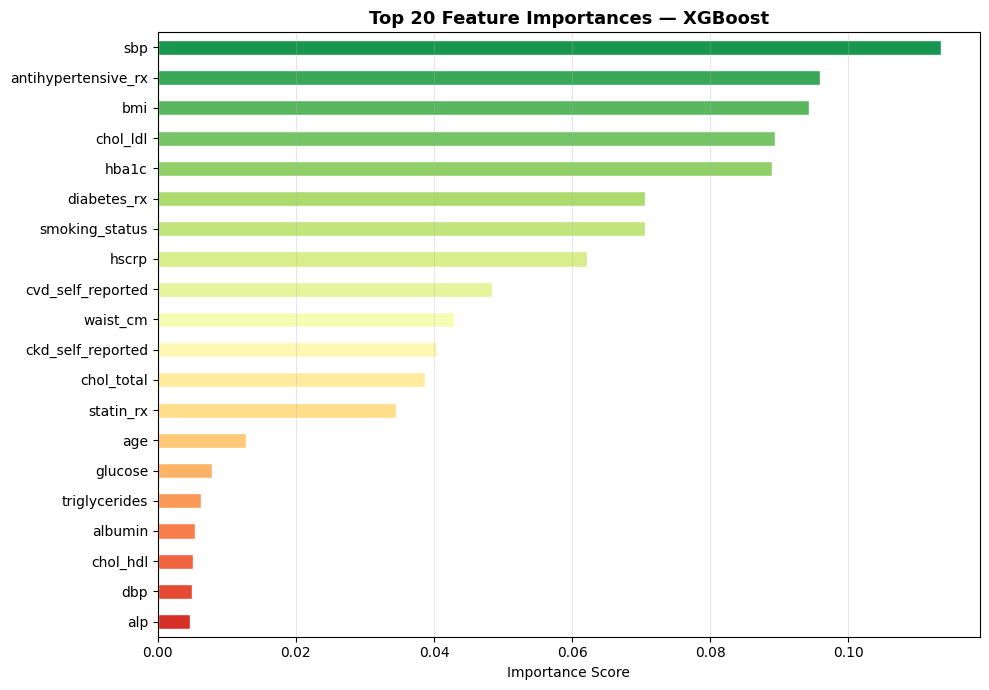

In [44]:
best_row   = metrics_df.iloc[0]
best_name  = best_row['Model']
best_model = trained_models[best_name]
X_best_test  = X_test_sc  if best_name == 'Logistic Regression' else X_test
X_best_train = X_train_sc if best_name == 'Logistic Regression' else X_train

print("=" * 60)
print(f"🏆 BEST MODEL : {best_name}")
print("=" * 60)
print(f"  Accuracy  : {best_row['Accuracy']:.4f}")
print(f"  Precision : {best_row['Precision']:.4f}")
print(f"  Recall    : {best_row['Recall']:.4f}")
print(f"  F1-Score  : {best_row['F1-Score']:.4f}")   # ✅ hyphen, not underscore
print(f"  ROC-AUC   : {best_row['ROC-AUC']:.4f}")    # ✅ hyphen, not underscore

print("\nDetailed Classification Report:")
print(classification_report(
    y_test, best_model.predict(X_best_test),
    target_names=label_names
))

# Feature Importance (tree-based models)
if hasattr(best_model, 'feature_importances_'):
    fi = pd.Series(best_model.feature_importances_, index=feature_names)
    fi = fi.sort_values(ascending=False).head(20)

    fig, ax = plt.subplots(figsize=(10, 7))
    colors_fi = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(fi)))
    fi.plot(kind='barh', ax=ax, color=colors_fi, edgecolor='white')
    ax.invert_yaxis()
    ax.set_title(f'Top 20 Feature Importances — {best_name}',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Importance Score')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig('plot_08_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig)

# CELL 12 ─ SHAP — Global Explainability

Computing SHAP values... (may take 1–2 minutes)
SHAP values ready — 3 class arrays, each shape (7500, 36)


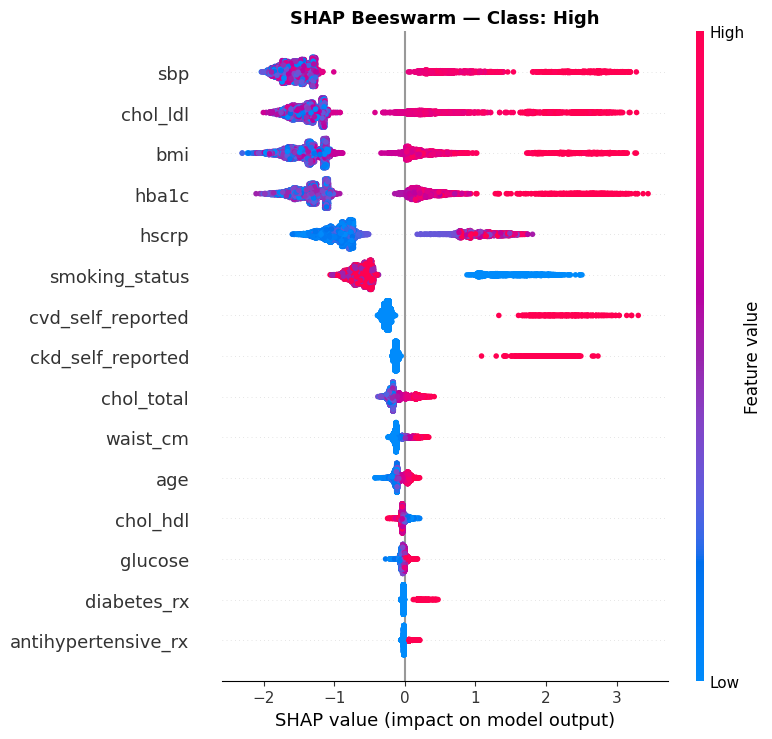

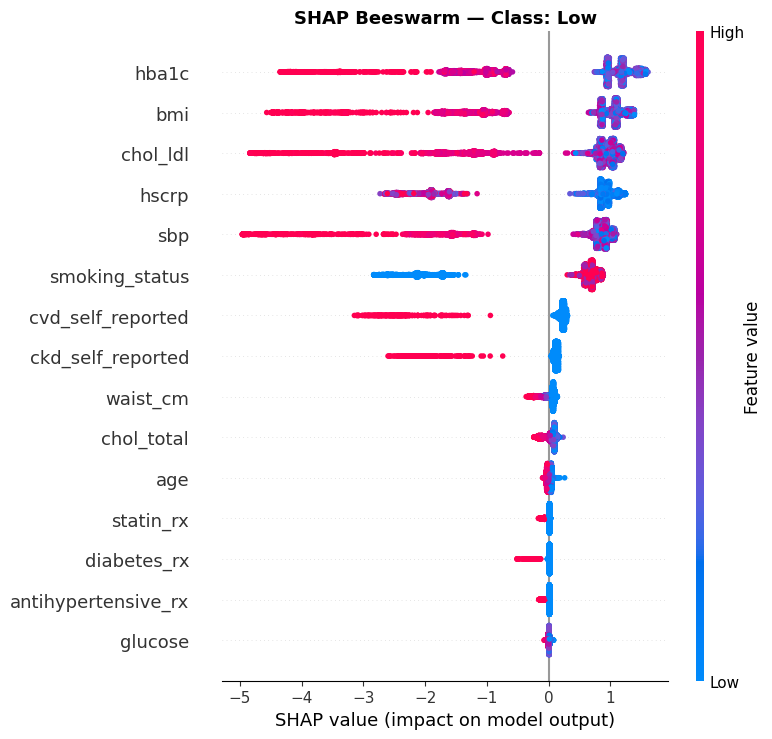

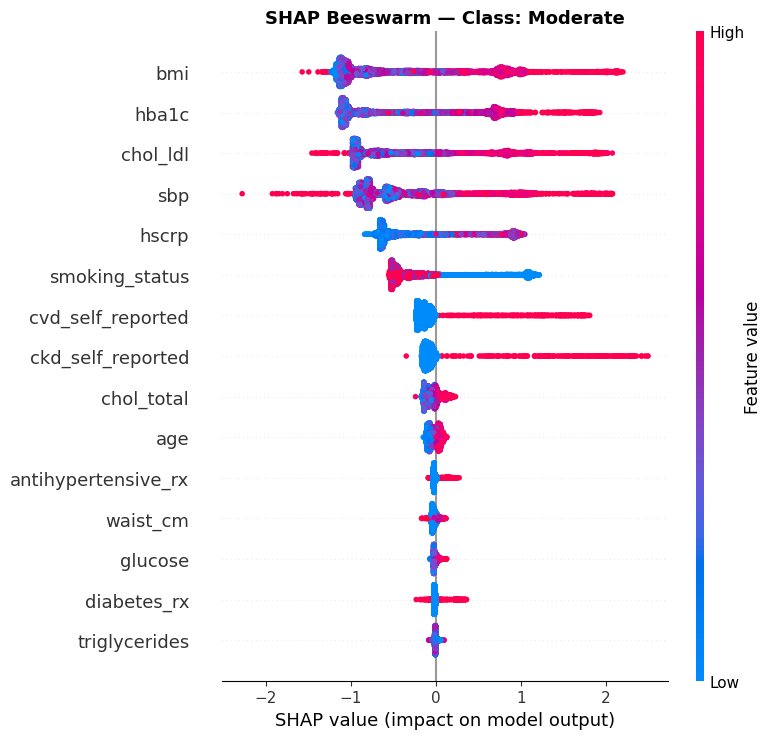


SHAP Global Feature Importance (Mean |SHAP|):


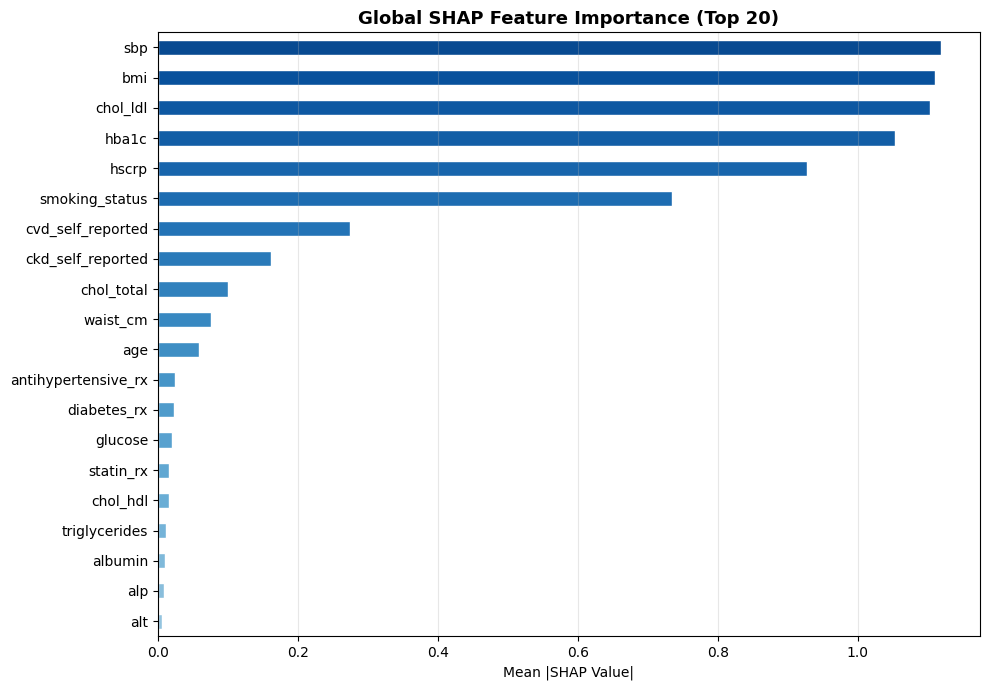

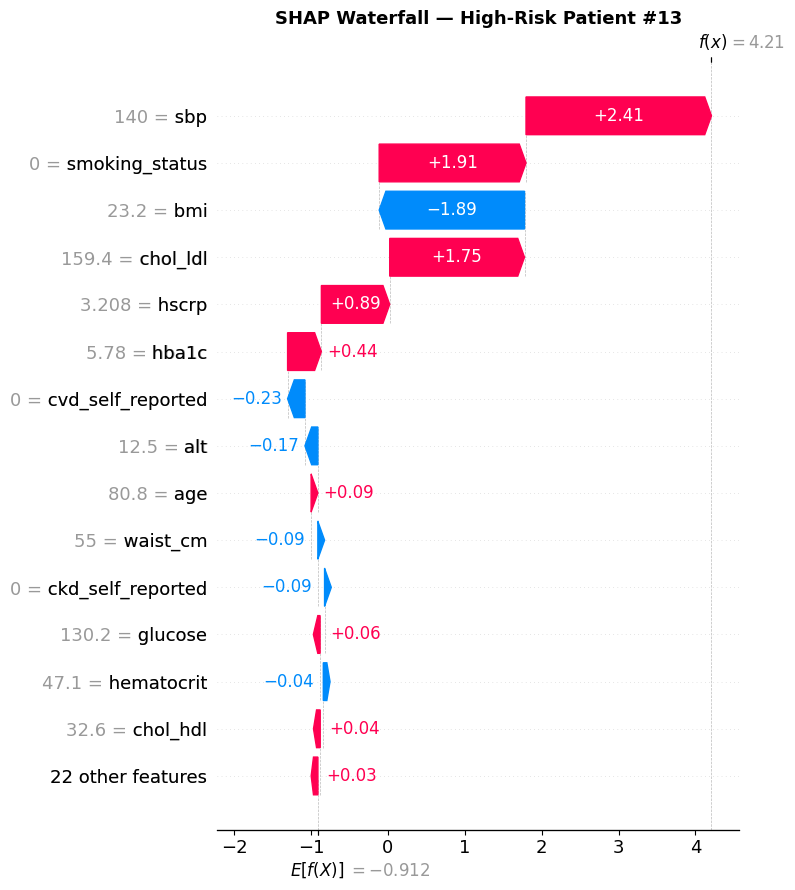

In [46]:
print("Computing SHAP values... (may take 1–2 minutes)")

background_size = 500
X_best_train_df = pd.DataFrame(X_best_train, columns=feature_names) \
                  if not isinstance(X_best_train, pd.DataFrame) else X_best_train
X_best_test_df  = pd.DataFrame(X_best_test,  columns=feature_names) \
                  if not isinstance(X_best_test,  pd.DataFrame) else X_best_test

background = shap.sample(X_best_train_df, background_size)

# ── Compute SHAP values
if best_name in ('Random Forest', 'Decision Tree', 'XGBoost'):
    explainer_shap = shap.TreeExplainer(best_model)
    shap_values_raw = explainer_shap.shap_values(X_best_test_df)
else:
    explainer_shap  = shap.KernelExplainer(best_model.predict_proba, background)
    shap_values_raw = explainer_shap.shap_values(X_best_test_df.iloc[:300])

# ── Normalise to always be a list of 2D arrays [class0, class1, class2]
#    TreeExplainer on XGBoost returns shape (n_samples, n_features, n_classes)
#    TreeExplainer on RF      returns a list  [array(n_samples, n_features), ...]
if isinstance(shap_values_raw, np.ndarray) and shap_values_raw.ndim == 3:
    # XGBoost 3-D case → split along last axis
    shap_values = [shap_values_raw[:, :, i] for i in range(shap_values_raw.shape[2])]
elif isinstance(shap_values_raw, list):
    shap_values = shap_values_raw          # RF / already a list
else:
    shap_values = [shap_values_raw]        # binary / single-output fallback

n_classes_shap = len(shap_values)
class_idx_map  = {label: i for i, label in enumerate(label_names)}
print(f"SHAP values ready — {n_classes_shap} class arrays, each shape {shap_values[0].shape}")

# ────────────────────────────────────────────────────────────
# SHAP Plot A: Beeswarm — one per class
# ────────────────────────────────────────────────────────────
for cls_label, cls_idx in class_idx_map.items():
    if cls_idx >= n_classes_shap:
        continue
    plt.figure(figsize=(10, 7))
    shap.summary_plot(
        shap_values[cls_idx],
        X_best_test_df,
        plot_type='dot',
        max_display=15,
        show=False,
        color_bar=True
    )
    plt.title(f'SHAP Beeswarm — Class: {cls_label}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'plot_09_shap_beeswarm_{cls_label.lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

# ────────────────────────────────────────────────────────────
# SHAP Plot B: Global bar (Mean |SHAP| across all classes)
# ────────────────────────────────────────────────────────────
print("\nSHAP Global Feature Importance (Mean |SHAP|):")

# ✅ Always average over the list → guarantees 1D result
mean_abs = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values], axis=0)  # shape (n_features,)

shap_importance = pd.Series(mean_abs, index=feature_names).sort_values(ascending=False)
top_shap = shap_importance.head(20)

fig, ax = plt.subplots(figsize=(10, 7))
colors_shap = plt.cm.Blues(np.linspace(0.4, 0.9, len(top_shap)))[::-1]
top_shap.plot(kind='barh', ax=ax, color=colors_shap, edgecolor='white')
ax.invert_yaxis()
ax.set_title('Global SHAP Feature Importance (Top 20)', fontsize=13, fontweight='bold')
ax.set_xlabel('Mean |SHAP Value|')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('plot_10_shap_global_importance.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)

# ────────────────────────────────────────────────────────────
# SHAP Plot C: Waterfall — one High-risk patient
# ────────────────────────────────────────────────────────────
high_risk_class   = class_idx_map.get('High', 2)
high_risk_indices = np.where(y_test.values == high_risk_class)[0]

if len(high_risk_indices) > 0 and high_risk_class < n_classes_shap:
    patient_idx = high_risk_indices[0]
    sv_patient  = shap_values[high_risk_class][patient_idx]

    ev = explainer_shap.expected_value
    base_val = (ev[high_risk_class]
                if isinstance(ev, (list, np.ndarray))
                else float(ev))

    shap_exp = shap.Explanation(
        values        = sv_patient,
        base_values   = base_val,
        data          = X_best_test_df.iloc[patient_idx].values,
        feature_names = feature_names
    )
    plt.figure(figsize=(12, 6))
    shap.waterfall_plot(shap_exp, max_display=15, show=False)
    plt.title(f'SHAP Waterfall — High-Risk Patient #{patient_idx}',
              fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('plot_11_shap_waterfall_highrisk.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

# CELL 13 ─ LIME — Local Explainability

Setting up LIME explainer...

High Risk Patient (Index 13)
  True label : High
  Predicted  : High
  Predict proba: {'High': np.float32(0.996), 'Low': np.float32(0.0), 'Moderate': np.float32(0.004)}


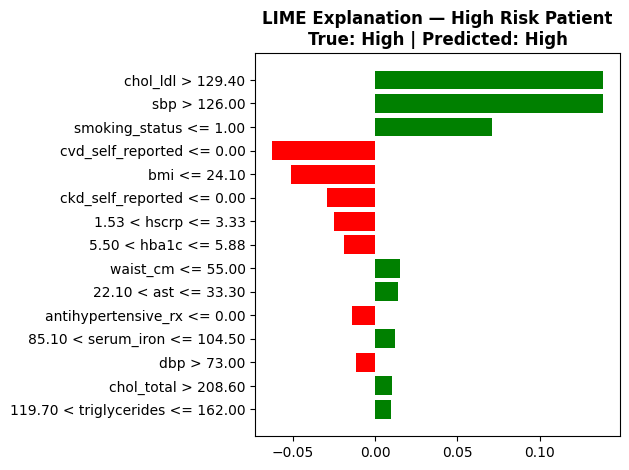


Low Risk Patient (Index 1)
  True label : Low
  Predicted  : Low
  Predict proba: {'High': np.float32(0.0), 'Low': np.float32(1.0), 'Moderate': np.float32(0.0)}


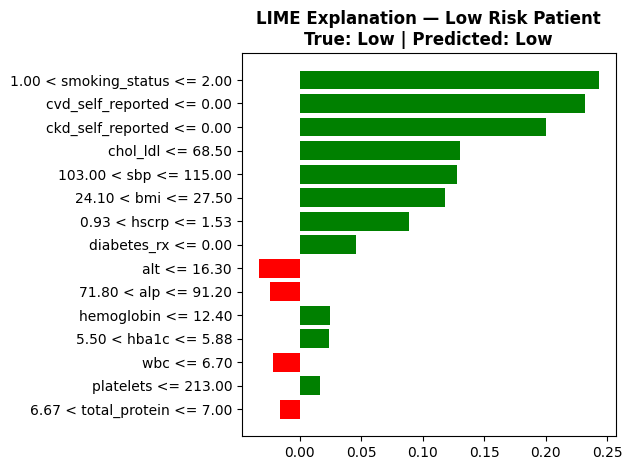


Moderate Risk Patient (Index 0)
  True label : Moderate
  Predicted  : Moderate
  Predict proba: {'High': np.float32(0.057), 'Low': np.float32(0.001), 'Moderate': np.float32(0.941)}


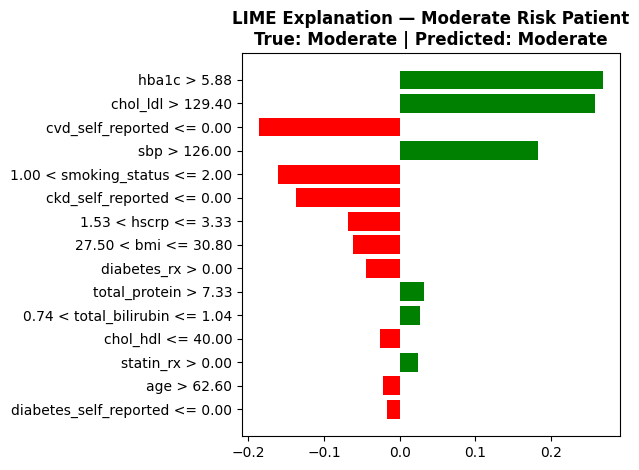

In [47]:
print("Setting up LIME explainer...")

X_test_np = X_best_test.values if isinstance(X_best_test, pd.DataFrame) else X_best_test

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data   = X_best_train.values
                      if isinstance(X_best_train, pd.DataFrame)
                      else X_best_train,
    feature_names   = feature_names,
    class_names     = label_names,
    mode            = 'classification',
    discretize_continuous = True,
    random_state    = SEED
)

def explain_patient(idx, label='Patient', save_prefix='lime'):
    """Generate and plot LIME explanation for one patient."""
    exp = lime_explainer.explain_instance(
        data_row      = X_test_np[idx],
        predict_fn    = best_model.predict_proba,
        num_features  = 15,
        top_labels    = 3
    )

    pred_class = best_model.predict(X_test_np[idx].reshape(1, -1))[0]
    true_class = y_test.values[idx]
    pred_label = label_names[pred_class]
    true_label = label_names[true_class]

    print(f"\n{label} (Index {idx})")
    print(f"  True label : {true_label}")
    print(f"  Predicted  : {pred_label}")
    print(f"  Predict proba: {dict(zip(label_names, np.round(best_model.predict_proba(X_test_np[idx].reshape(1,-1))[0], 3)))}")

    fig = exp.as_pyplot_figure(label=pred_class)
    plt.title(f'LIME Explanation — {label}\nTrue: {true_label} | Predicted: {pred_label}',
              fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{save_prefix}_{label.lower().replace(" ","_")}.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    return exp

# ── LIME for 3 patients: one per risk class
for target_label in label_names:
    target_cls = class_idx_map[target_label]
    idx_list = np.where(y_test.values == target_cls)[0]
    if len(idx_list) > 0:
        explain_patient(
            idx_list[0],
            label=f'{target_label} Risk Patient',
            save_prefix='plot_12_lime'
        )

# CELL 14 ─ SHAP Interaction (Dependence Plot) — top features

<Figure size 800x500 with 0 Axes>

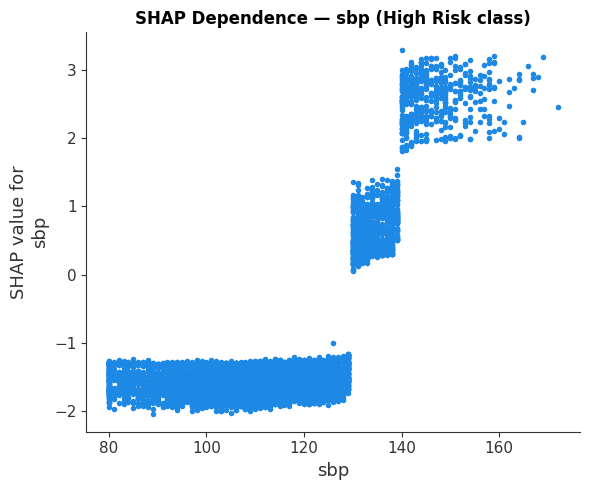

<Figure size 800x500 with 0 Axes>

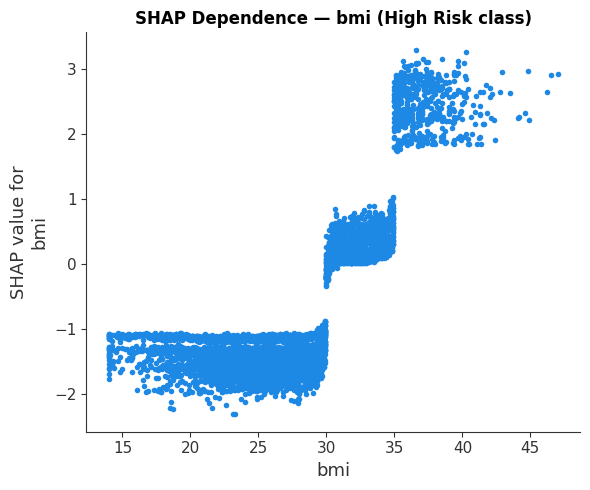

In [48]:
top2 = shap_importance.head(2).index.tolist()
X_test_df = pd.DataFrame(X_best_test, columns=feature_names) \
            if not isinstance(X_best_test, pd.DataFrame) else X_best_test

if isinstance(shap_values, list):
    sv_high = shap_values[class_idx_map.get('High', 2)]
else:
    sv_high = shap_values

for feat in top2:
    plt.figure(figsize=(8, 5))
    shap.dependence_plot(
        feat, sv_high, X_test_df,
        interaction_index=None,
        show=False
    )
    plt.title(f'SHAP Dependence — {feat} (High Risk class)',
              fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'plot_13_shap_dependence_{feat}.png', dpi=150, bbox_inches='tight')
    plt.show()

# CELL 15 ─ Final Summary Report

In [50]:
print("\n" + "=" * 70)
print("  FINAL SUMMARY — CDSS THESIS ML PIPELINE")
print("=" * 70)
print(f"\n  Dataset         : 50,000 records × {X.shape[1]} features")
print(f"  Train/Val/Test  : {X_train.shape[0]:,} / {X_val.shape[0]:,} / {X_test.shape[0]:,}")
print(f"  Classes         : {label_names}")
print(f"\n  ── MODEL RESULTS ──")
print(metrics_df[['Model','Accuracy','Precision','Recall','F1-Score','ROC-AUC']].to_string(index=False))
print(f"\n  🏆 Best Model   : {best_name}")
print(f"     ROC-AUC      : {best_row['ROC-AUC']:.4f}")   # ✅ hyphen
print(f"     F1-Score     : {best_row['F1-Score']:.4f}")   # ✅ hyphen
print(f"\n  ── XAI APPLIED ──")
print(f"  SHAP : Global beeswarm, bar, waterfall, dependence plots")
print(f"  LIME : Per-patient local explanations (one per risk class)")
print(f"\n  Top SHAP features:")
for feat, val in shap_importance.head(5).items():
    print(f"    {feat:<25} : {val:.4f}")
print("\n" + "=" * 70)
print("  ✅ Pipeline complete. All plots saved as PNG files.")
print("=" * 70)


  FINAL SUMMARY — CDSS THESIS ML PIPELINE

  Dataset         : 50,000 records × 36 features
  Train/Val/Test  : 34,998 / 7,502 / 7,500
  Classes         : ['High', 'Low', 'Moderate']

  ── MODEL RESULTS ──
              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
            XGBoost    0.9919     0.9920  0.9919    0.9918   0.9997
      Random Forest    0.9515     0.9518  0.9515    0.9503   0.9955
      Decision Tree    0.9740     0.9749  0.9740    0.9743   0.9921
Logistic Regression    0.7980     0.8282  0.7980    0.8080   0.9228

  🏆 Best Model   : XGBoost
     ROC-AUC      : 0.9997
     F1-Score     : 0.9918

  ── XAI APPLIED ──
  SHAP : Global beeswarm, bar, waterfall, dependence plots
  LIME : Per-patient local explanations (one per risk class)

  Top SHAP features:
    sbp                       : 1.1184
    bmi                       : 1.1103
    chol_ldl                  : 1.1032
    hba1c                     : 1.0533
    hscrp                     : 0.9278

  ✅ Pipeline